# Customer Segmentation Analysis

This project performs customer segmentation using RFM analysis and K-means clustering on retail transaction data.

## Objectives
- Clean and prepare transactional data
- Create RFM (Recency, Frequency, Monetary) features
- Segment customers using clustering
- Generate business insights for targeting and retention

In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

Matplotlib is building the font cache; this may take a moment.


In [2]:
#Load Data
df = pd.read_excel("data/raw/Online Retail.xlsx")

print("Shape:", df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
#Clean Data
# Remove missing customers
df = df.dropna(subset=["CustomerID"])

# Remove returns
df = df[df["Quantity"] > 0]

# Remove invalid prices
df = df[df["UnitPrice"] > 0]

# Convert types
df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create total price
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print("Cleaned shape:", df.shape)

Cleaned shape: (397884, 9)


In [4]:

#RFM Features
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [5]:
#Scale Data
features = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

In [6]:
#K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,3
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,0
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,1


In [7]:
#Label Segments
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

# Rank clusters
cluster_summary["Score"] = (
    -cluster_summary["Recency"] +
    cluster_summary["Frequency"] +
    cluster_summary["Monetary"] / 100
)

cluster_summary = cluster_summary.sort_values("Score", ascending=False)

labels = ["VIP", "Loyal", "Potential", "At-Risk"]

cluster_summary["Segment"] = labels

cluster_map = cluster_summary["Segment"].to_dict()

rfm["Segment"] = rfm["Cluster"].map(cluster_map)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,3,Loyal
1,12347,2,7,4310.00,0,Potential
2,12348,75,4,1797.24,0,Potential
3,12349,19,1,1757.55,0,Potential
4,12350,310,1,334.40,1,At-Risk


In [8]:
#Segment Summary
segment_summary = rfm.groupby("Segment").agg({
    "CustomerID": "count",
    "Monetary": "sum"
}).reset_index()

segment_summary.columns = ["Segment", "Customers", "Revenue"]

segment_summary

,Segment,Customers,Revenue
0,At-Risk,1067,512818.851
1,Loyal,204,2592654.460
2,Potential,3054,4150536.513
3,VIP,13,1655398.080


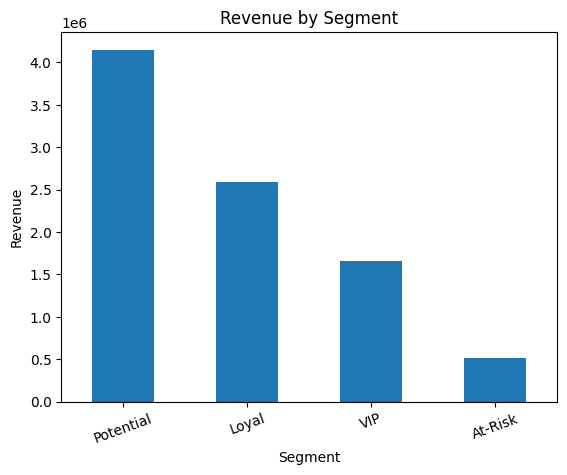

In [9]:
#Visuals
#Revenue by segment
segment_summary.sort_values("Revenue", ascending=False).plot(
    x="Segment", y="Revenue", kind="bar", legend=False
)

plt.title("Revenue by Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=20)
plt.show()

In [10]:
#Save Files
rfm.to_csv("data/processed/rfm_segments.csv", index=False)
segment_summary.to_csv("data/processed/segment_summary.csv", index=False)

print("Saved processed files.")

Saved processed files.


## Key Insights

- VIP customers generate the highest revenue and should be prioritized for retention.
- Loyal customers purchase frequently and are strong candidates for upselling.
- Potential customers show moderate engagement and can be nurtured with targeted campaigns.
- At-risk customers have low engagement and may require win-back strategies.

## Business Impact
This segmentation enables more effective targeting, improved retention strategies, and increased revenue through data-driven decision-making.